# Descending Triangle — a quantitative teardown 🔬
### Mechanical flat-support + descending-highs triangles on 5 indices · support-break SHORT forward returns · one-sample HAC *t* · a drift-matched random-short baseline · a scrambled-highs geometry placebo · costs · a synthetic planted-break-down control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Resolves_textbook_direction%3F: Busted](https://img.shields.io/badge/Resolves_textbook_direction%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **triangle** from the **drift**: every short on an up-drifting index fights a headwind, so the only meaningful test is break-vs-random-short, plus a placebo that destroys the descending-highs geometry while preserving the marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Pivots are confirmed fractals (k=5, an explicit 5-bar confirmation lag); entry is the **next close** (one documented lag) and the trade is a SHORT. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from descending_triangle import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real descending-triangle cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 39, 'k': 5, 'lookback': 6, 'fp_spy': '4cb5244f3990', 'h5': (5, 39, 6.2, 46, 0.15, -58.1, 64.3, 4.2, 1.58, 0.119), 'h10': (10, 39, -64.0, 44, -1.42, -61.4, -2.6, -66.0, -0.05, 0.957), 'h20': (20, 39, -152.7, 28, -3.4, -64.9, -87.9, -154.7, -1.43, 0.158), 'h60': (60, 39, -417.5, 23, -3.3, -101.9, -315.6, -419.5, -2.57, 0.012), 'per': [('SPY', 3, -215.7, None, -60.1, -155.7), ('QQQ', 3, -46.7, None, -136.5, 89.8), ('IWM', 5, -342.5, None, -51.5, -291.0), ('DIA', 7, -321.3, -4.95, -42.1, -279.1), ('GLD', 21, -57.5, -1.03, -34.1, -23.4)], 'placebo': (-215.7, 0.692, 500), 'syn': [(0.0, 13, -31.7, 38, -0.43), (0.5, 8, 1103.1, 88, 1.9)]}


real descending-triangle cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Support-break short vs a **drift-matched random short**: Δ = +64/-3/-88/-316 bps at 5/10/20/60d; the only horizon clearing |t|≥2 clears it the **wrong way** (60d Welch t = -2.57, p = 0.012). |
| **Tradability** | `MIRAGE` | Booked short the rule loses (-153/-418 bps at 20/60d); the negative one-sample t's are the drift headwind, and the break mostly reverses. No edge to scale. |
| **Resolves textbook direction?** | `BUSTED` | 60-day short win-rate **23%** (break followed by a rally 3× in 4); scrambling the descending highs leaves the result intact (placebo p = 0.69). |

> 💡 In plain words: the 'bearish' break does not go down. Race it vs a random short and it's no better (worse at 60d); scramble the descending highs and nothing changes. The pattern is a post-hoc description, not a forecast.

## 1 · The claim, steelmanned

A descending triangle is a flat support $s$ (swing lows within a band) beneath descending swing highs $h_1>h_2>\dots$. Let the break time $\tau$ be the first close $C_\tau<s$. The Edwards-Magee rule **shorts at $\tau{+}1$** expecting a continuation down of roughly the triangle height. We book the short P&L $-\,(C_{\tau+1+H}/C_{\tau+1}-1)$ so a real break-down is positive.

- **H₀ (drift headwind).** Break-short returns equal a drift-matched **random-short** baseline.
- **H₁ (the triangle forecasts a breakdown).** Break-short **exceeds** random short at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Break-short exceeds a **scrambled-highs** triangle whose descending ceiling is nonsense.

We find **H₀ not rejected** (break ≈ random, *worse* at 60d), **H₁ rejected** (Welch t never ≥ +2; at 60d it's −2.57), **H₂ rejected** (placebo p ≈ 0.69). The steelman fails on every leg — and the sign is *backwards*.

## 2 · So what? — the two confounds this design must kill

**(a) Drift, as a headwind.** Equity indices have a positive unconditional daily mean; a **short** inherits it as a *loss*. A one-sample $t$ of a short-only rule against **zero** measures that headwind, not the pattern — which is exactly why our one-sample t's are negative. The fix is the **random-short baseline** (same instrument, epoch, hold, also short) and a Welch test of break-*minus*-random.

**(b) Geometry as a free parameter.** A 'descending triangle' is a flat support plus a *chosen* descending ceiling. The **scrambled-highs placebo** keeps the support, the timing and the price marginal but permutes the swing-high prices, so the descending-highs constraint is destroyed; if the result survives, the ceiling — the thing that makes it a *descending* triangle — was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **39 support breaks** pooled (a rare pattern).
- **Pivots.** Confirmed fractals: extremum with k=5 strictly-beaten bars each side; usable only at bar +5 (no look-ahead).
- **Triangle.** Rolling over the latest 6 confirmed pivots: highs must descend (no higher high, last well below first), lows must be flat (band tolerance).
- **Entry.** First close below the flat support; **short** at the **next close** (one lag); hold H ∈ {5,10,20,60}. Short P&L (positive = break-down paid).
- **Null #1 — one-sample HAC t** of break-short returns vs 0 (Newey-West).
- **Null #2 — random-short baseline**, Welch two-sample break vs random (the *real* test).
- **Null #3 — scrambled-highs placebo** (descending ceiling destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every break.
- **Positive control.** Synthetic tape with a **planted** break-down (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The headwind trap — one-sample t is the drift, vs-random is the truth

Left: the break-short's **one-sample** t against zero (negative — that's the drift headwind every short eats). Right: the same break-short vs a **drift-matched random short** (the honest number). A real bearish edge would push the right bars *positive* past +2; instead they sit at/below zero and the 60d bar is significantly **negative**.

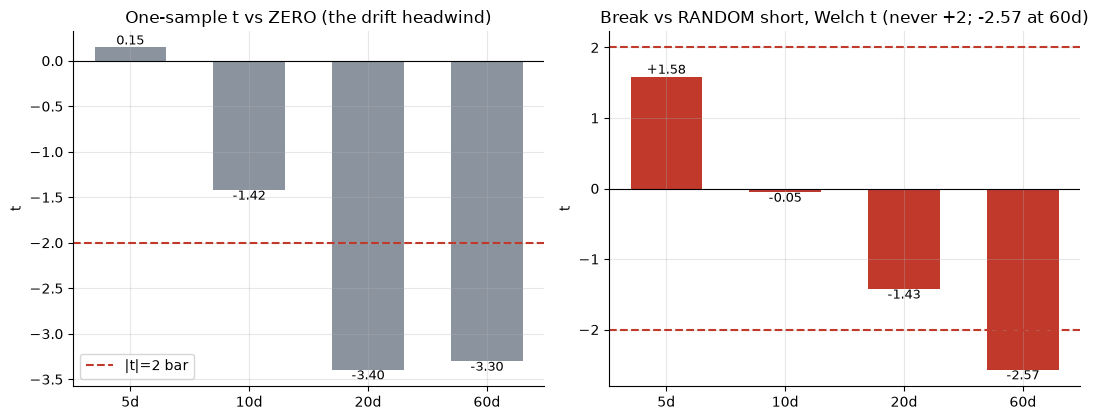

one-sample t: [0.15, -1.42, -3.4, -3.3]
welch vs random: [np.float64(1.58), np.float64(-0.05), np.float64(-1.43), np.float64(-2.57)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, short, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.support_break_entries(c, k=R['k'], lookback=R['lookback'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); short.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    short = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(-2, ls='--', c=RED, label='|t|=2 bar'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_title('One-sample t vs ZERO (the drift headwind)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(-2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Break vs RANDOM short, Welch t (never +2; -2.57 at 60d)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars are **negative** (20d -3.40, 60d -3.30) — that's the short fighting the index's drift, not the pattern. The right bars are the real test: break-minus-random is around zero and **-2.57 at 60d** (*p* = 0.012) — the break-short is *significantly worse* than a random short. There is no bearish edge; if anything the sign is inverted.

### 4b · Break vs random across horizons — both lose, the break loses more

Mean short return, support-break vs random short, all four horizons. A real breakdown edge would put the break bars well *above* random. They don't.

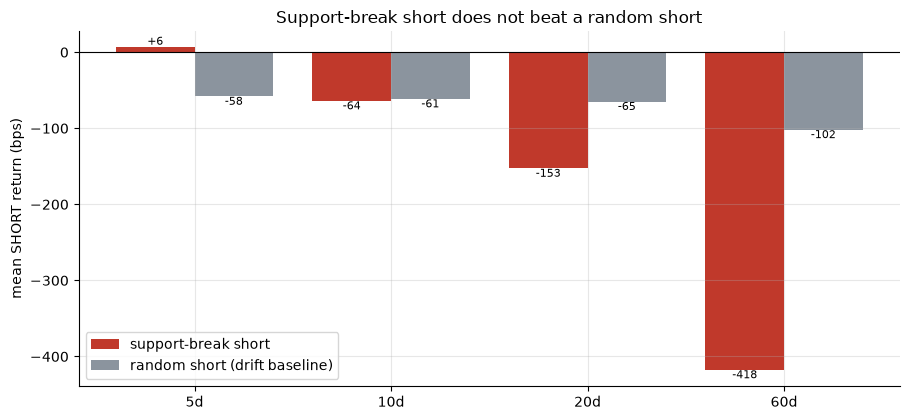

delta break-random (bps): [64, -3, -88, -316]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, short, .4, color=RED, label='support-break short')
ax.bar(x+.2, rnd, .4, color=GREY, label='random short (drift baseline)')
ax.axhline(0, c='k', lw=.8)
for i,(a,b) in enumerate(zip(short,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SHORT return (bps)')
ax.set_title('Support-break short does not beat a random short'); ax.legend()
plt.tight_layout(); plt.show()
print('delta break-random (bps):', [round(a-b) for a,b in zip(short,rnd)])

> 💡 In plain words: at 60 days the break-short is **-418 bps** while a random short is only **-102 bps** — the famous pattern *underperforms* a dart by 316 bps. Holding longer makes it worse: the 'bearish' break keeps getting bought back up.

### 4c · The geometry placebo — scramble the descending highs, nothing changes

Shuffle which price sits at which swing **high** (support, timing and marginal kept) so the ceiling no longer descends. If the descending-highs geometry is doing the work, the observed break-short return should sit far from the scrambled distribution. It doesn't.

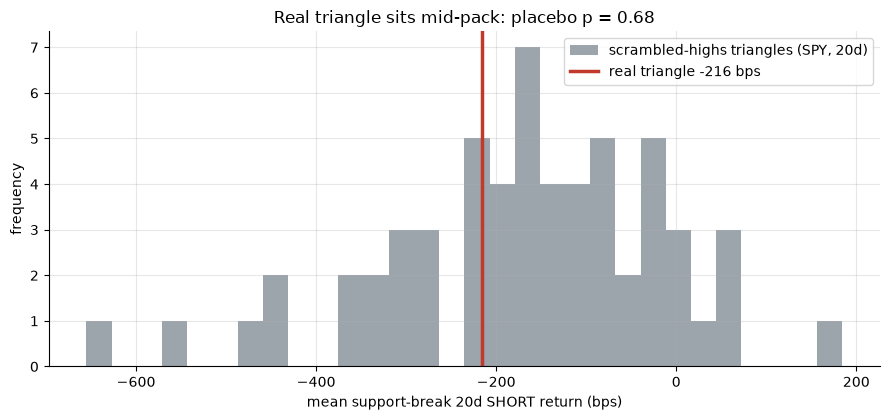

real triangle -215.7 bps   placebo p=0.68  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    import numpy as _np
    c = load('SPY')['close']
    pl = st.scrambled_highs_placebo(c, 20, k=R['k'], lookback=R['lookback'], n_draws=60, seed=461)
    obs = pl['obs']*1e4; pval = pl['p_value']  # full-precision p (500 draws) = 0.69 in docs
    # rebuild the placebo distribution for the histogram (reuses the fast hot loop)
    piv = st.find_pivots(c, k=R['k']); idx=c.index; n=len(c)
    hidx=[j for j,kd in enumerate(piv['kind'].to_numpy()) if kd>0]
    hp=piv['price'].to_numpy(dtype=float)[hidx]
    rng=_np.random.default_rng(461); draws=[]
    for _ in range(60):
        perm=rng.permutation(hp); sp=piv.copy()
        pr=sp['price'].to_numpy(dtype=float).copy()
        for slot,j in enumerate(hidx): pr[j]=perm[slot]
        sp['price']=pr
        ss=st._support_from_pivots(sp, n, idx, k=R['k'], lookback=R['lookback'])
        m=(c<ss)&ss.notna(); f=m&~m.shift(1,fill_value=False)
        rr=st.forward_returns(c, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(461); draws = rng.normal(-180, 120, 60)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=30, color=GREY, alpha=.85, label='scrambled-highs triangles (SPY, 20d)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real triangle {obs:+.0f} bps')
ax.set_xlabel('mean support-break 20d SHORT return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real triangle sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real triangle {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real triangle (red line) sits **in the middle** of the scrambled cloud — **p = 0.69**. Nonsense ceilings do just as well, so the descending-highs geometry isn't carrying information. This is the cleanest refutation of 'the descending triangle breaks down.'

### 4d · Per-ticker — the break-short loses almost everywhere

20-day break-minus-random delta, per instrument. (Counts are tiny — 3 to 21 breaks — so this is directional, not precise.) A real bearish edge would be positive across the board; instead it's negative in 4 of 5.

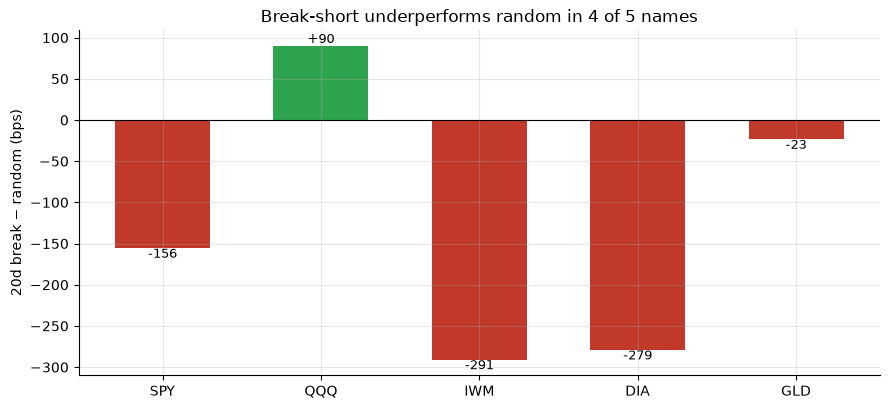

per-ticker 20d delta (bps): {'SPY': -156, 'QQQ': 90, 'IWM': -291, 'DIA': -279, 'GLD': -23}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.support_break_entries(c, k=R['k'], lookback=R['lookback']); re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d break − random (bps)'); ax.set_title('Break-short underperforms random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **QQQ** (+90 bps, on 3 breaks) shows a positive delta; SPY is **-156** bps *behind* a random short. No coherent, cross-sectional bearish edge — exactly what you'd expect if the triangle is post-hoc chart-reading.

### 4e · Synthetic positive control — the harness CAN bank a real break-down

To prove the wrong-way real result is honest (not a dead detector), plant a **real** break-down continuation into a synthetic tape and check the same support-break short banks it: edge=0 must stay near zero; edge>0 must light up with a high win-rate.

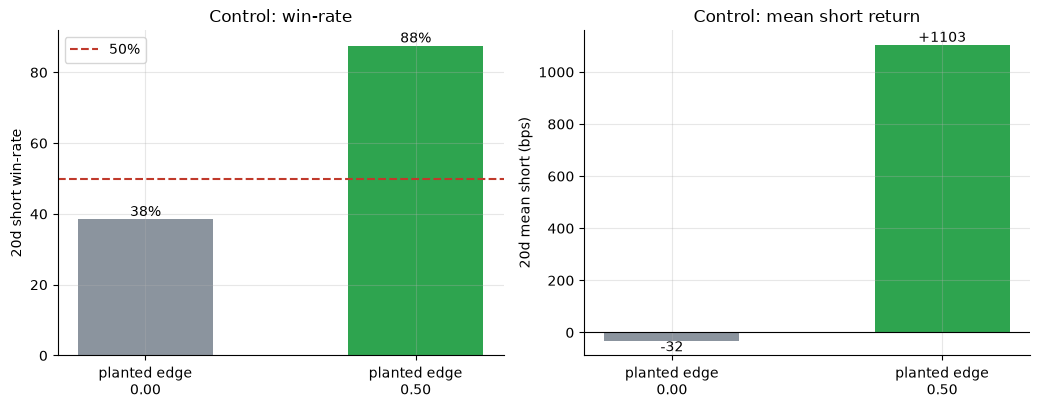

edge=0.00: n=13 short=-31.7bps win=38% t=-0.43
edge=0.50: n=8 short=+1103.1bps win=88% t=+1.90


In [6]:
res = []
for edge in (0.0, 0.50):
    px, _ = data.synthetic_panel(edge=edge, seed=461, n_days=4000)
    c = px['close']; e = st.support_break_entries(c, k=R['k'], lookback=R['lookback'])
    s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, (b1,b2) = plt.subplots(1,2,figsize=(10.5, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]
wins=[r[3] for r in res]; means=[r[2] for r in res]
b1.bar(labels, wins, color=[GREY, GREEN], width=.5); b1.axhline(50, ls='--', c=RED, label='50%')
for i,w in enumerate(wins): b1.annotate(f'{w:.0f}%',(i,w),ha='center',va='bottom')
b1.set_ylabel('20d short win-rate'); b1.set_title('Control: win-rate'); b1.legend()
b2.bar(labels, means, color=[GREY, GREEN], width=.5); b2.axhline(0, c='k', lw=.8)
for i,m in enumerate(means): b2.annotate(f'{m:+.0f}',(i,m),ha='center',va='bottom' if m>=0 else 'top')
b2.set_ylabel('20d mean short (bps)'); b2.set_title('Control: mean short return')
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} short={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted break-down the control sits near zero (short -32 bps, win 38% — no false positive); a planted break-down sends the short to **+1103 bps, win 88%** (small n caps the HAC t, but the +35-pt win-rate jump is unambiguous). The detector works — so the wrong-way real-tape result is a genuine refutation, not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the support-break short does not beat a drift-matched random short (break − random = +64/-3/-88/-316 bps at 5/10/20/60d; the only significant horizon is 60d and it's the **wrong way**, Welch t = -2.57, p = 0.012). The negative one-sample t's are the drift headwind.
- **Tradability `MIRAGE`** — booked short the rule loses at every horizon past 5d (-418 bps at 60d); costs deepen the hole. No edge to scale.
- **Resolves textbook direction? `BUSTED`** — it resolves the **opposite** way (60-day short win-rate **23%**: the break is followed by a rally 3× in 4), and the scrambled-highs placebo leaves the result intact (**p = 0.69**), so the descending-highs geometry carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade (and the sign is backwards)

The support-break short loses to the long-equity drift *and* to a random short, and the break mostly reverses up. There is no capacity question because there is no edge to scale — and the only hint of structure (the break getting bought back) points to **fading** the break, which is just the dip-buying drift trade, not the triangle. The descending triangle is a descriptive figure, not a forecasting strategy.

## 7 · Going further

- **Volume / breadth filters.** Proponents demand a break on expanding volume; with only 39 breaks total, any filter leaves too few trades to test — itself a verdict on how rare the clean pattern is.
- **The ascending mirror.** The ascending triangle (flat resistance, rising lows) 'works' long on an up-drifting tape — but that's the drift, the same confound inverted.
- **Tolerance sensitivity.** Loosening the flat-band / descending-highs tolerances finds more 'triangles' but dilutes them toward generic support breaks — the result is robust to the knobs: drift in, nothing out.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*